# Predicting Energy Consumption in Smart Buildings Using Explainable Machine Learning
This notebook builds a complete pipeline to pre-process the UCI Energy Efficiency Dataset, train multiple regression models (including Linear Regression, Random Forest, Gradient Boosting, KNN, and RNNs), and evaluate their performance.

## A. Data Preparation
We will load the data from `energy.xlsx`, handle any required cleaning, and split into train/test sets, followed by normalization.


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Loading dataset from energy.xlsx...")
df = pd.read_excel('energy.xlsx')

columns = {
    "X1": "Relative_Compactness",
    "X2": "Surface_Area",
    "X3": "Wall_Area",
    "X4": "Roof_Area",
    "X5": "Overall_Height",
    "X6": "Orientation",
    "X7": "Glazing_Area",
    "X8": "Glazing_Area_Distribution",
    "Y1": "Heating_Load",
    "Y2": "Cooling_Load"
}
df = df.rename(columns=columns)
df.head()


Loading dataset from energy.xlsx...


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Missing values per column:\n", df.isnull().sum())
df = df.dropna()

X = df.drop(['Heating_Load', 'Cooling_Load'], axis=1)
y_heat = df['Heating_Load']
y_cool = df['Cooling_Load']

X_train, X_test, y_heat_train, y_heat_test = train_test_split(
    X, y_heat, test_size=0.2, random_state=42
)
_, _, y_cool_train, y_cool_test = train_test_split(
    X, y_cool, test_size=0.2, random_state=42
)

scaler_heat = StandardScaler()
X_heat_train_scaled = scaler_heat.fit_transform(X_train)
X_heat_test_scaled = scaler_heat.transform(X_test)

scaler_cool = StandardScaler()
X_cool_train_scaled = scaler_cool.fit_transform(X_train)
X_cool_test_scaled = scaler_cool.transform(X_test)

print("Heating train shape:", X_heat_train_scaled.shape, "Heating test shape:", X_heat_test_scaled.shape)
print("Cooling train shape:", X_cool_train_scaled.shape, "Cooling test shape:", X_cool_test_scaled.shape)

Missing values per column:
 Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64
Heating train shape: (614, 8) Heating test shape: (154, 8)
Cooling train shape: (614, 8) Cooling test shape: (154, 8)


## B. Baseline Model Development
A baseline prediction model will first be implemented using Linear Regression.


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import math

lr_heat_model = LinearRegression()
lr_heat_model.fit(X_heat_train_scaled, y_heat_train)
lr_heat_preds = lr_heat_model.predict(X_heat_test_scaled)
lr_heat_mse = mean_squared_error(y_heat_test, lr_heat_preds)
lr_heat_rmse = math.sqrt(lr_heat_mse)
lr_heat_r2 = r2_score(y_heat_test, lr_heat_preds)
lr_heat_mae = mean_absolute_error(y_heat_test, lr_heat_preds)
lr_heat_mape = np.mean(np.abs((y_heat_test - lr_heat_preds) / y_heat_test)) * 100

print("Linear Regression Performance (Heating Load):")
print(f"MSE: {lr_heat_mse:.4f}")
print(f"RMSE: {lr_heat_rmse:.4f}")
print(f"R2 : {lr_heat_r2:.4f}")
print(f"MAE:  {lr_heat_mae:.4f}")
print(f"MAPE: {lr_heat_mape:.4f}%")
print("\n")

lr_cool_model = LinearRegression()
lr_cool_model.fit(X_cool_train_scaled, y_cool_train)
lr_cool_preds = lr_cool_model.predict(X_cool_test_scaled)
lr_cool_mse = mean_squared_error(y_cool_test, lr_cool_preds)
lr_cool_rmse = math.sqrt(lr_cool_mse)
lr_cool_r2 = r2_score(y_cool_test, lr_cool_preds)
lr_cool_mae = mean_absolute_error(y_cool_test, lr_cool_preds)
lr_cool_mape = np.mean(np.abs((y_cool_test - lr_cool_preds) / y_cool_test)) * 100

print("Linear Regression Performance (Cooling Load):")
print(f"MSE: {lr_cool_mse:.4f}")
print(f"RMSE: {lr_cool_rmse:.4f}")
print(f"R2 : {lr_cool_r2:.4f}")
print(f"MAE:  {lr_cool_mae:.4f}")
print(f"MAPE: {lr_cool_mape:.4f}%")

Linear Regression Performance (Heating Load):
MSE: 9.1532
RMSE: 3.0254
R2 : 0.9122
MAE:  2.1821
MAPE: 10.2589%


Linear Regression Performance (Cooling Load):
MSE: 9.8934
RMSE: 3.1454
R2 : 0.8932
MAE:  2.1953
MAPE: 8.4787%


## C. Advanced Machine Learning Models
We will now implement Random Forest Regression, Gradient Boosting Regression, K-Nearest Neighbors, and eventually RNNs.


In [5]:
results = {}
results["Linear Regression (Heating Load)"] = {"MSE": lr_heat_mse, "RMSE": lr_heat_rmse, "R2": lr_heat_r2, "MAE": lr_heat_mae, "MAPE": lr_heat_mape, "Predictions": lr_heat_preds, "Model": lr_heat_model}
results["Linear Regression (Cooling Load)"] = {"MSE": lr_cool_mse, "RMSE": lr_cool_rmse, "R2": lr_cool_r2, "MAE": lr_cool_mae, "MAPE": lr_cool_mape, "Predictions": lr_cool_preds, "Model": lr_cool_model}


### Random Forest Regression
Training a Random Forest Regressor.


In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_heat_model = RandomForestRegressor(random_state=42)
rf_heat_model.fit(X_heat_train_scaled, y_heat_train)
rf_heat_preds = rf_heat_model.predict(X_heat_test_scaled)
rf_heat_mse = mean_squared_error(y_heat_test, rf_heat_preds)
rf_heat_rmse = math.sqrt(rf_heat_mse)
rf_heat_r2 = r2_score(y_heat_test, rf_heat_preds)
rf_heat_mae = mean_absolute_error(y_heat_test, rf_heat_preds)
rf_heat_mape = np.mean(np.abs((y_heat_test - rf_heat_preds) / y_heat_test)) * 100
    
results["Random Forest (Heating Load)"] = {"MSE": rf_heat_mse, "RMSE": rf_heat_rmse, "R2": rf_heat_r2, "MAE": rf_heat_mae, "MAPE": rf_heat_mape, "Predictions": rf_heat_preds, "Model": rf_heat_model}
    
print("--- Random Forest (Heating Load) ---")
print(f"MSE:  {rf_heat_mse:.4f}")
print(f"RMSE: {rf_heat_rmse:.4f}")
print(f"R2:   {rf_heat_r2:.4f}")
print(f"MAE:  {rf_heat_mae:.4f}")
print(f"MAPE: {rf_heat_mape:.4f}%")
print("\n")

rf_cool_model = RandomForestRegressor(random_state=42)
rf_cool_model.fit(X_cool_train_scaled, y_cool_train)
rf_cool_preds = rf_cool_model.predict(X_cool_test_scaled)
rf_cool_mse = mean_squared_error(y_cool_test, rf_cool_preds)
rf_cool_rmse = math.sqrt(rf_cool_mse)
rf_cool_r2 = r2_score(y_cool_test, rf_cool_preds)
rf_cool_mae = mean_absolute_error(y_cool_test, rf_cool_preds)
rf_cool_mape = np.mean(np.abs((y_cool_test - rf_cool_preds) / y_cool_test)) * 100
    
results["Random Forest (Cooling Load)"] = {"MSE": rf_cool_mse, "RMSE": rf_cool_rmse, "R2": rf_cool_r2, "MAE": rf_cool_mae, "MAPE": rf_cool_mape, "Predictions": rf_cool_preds, "Model": rf_cool_model}
    
print("--- Random Forest (Cooling Load) ---")
print(f"MSE:  {rf_cool_mse:.4f}")
print(f"RMSE: {rf_cool_rmse:.4f}")
print(f"R2:   {rf_cool_r2:.4f}")
print(f"MAE:  {rf_cool_mae:.4f}")
print(f"MAPE: {rf_cool_mape:.4f}%")


--- Random Forest (Heating Load) ---
MSE:  0.2473
RMSE: 0.4973
R2:   0.9976
MAE:  0.3582
MAPE: 1.4938%


--- Random Forest (Cooling Load) ---
MSE:  2.9778
RMSE: 1.7256
R2:   0.9679
MAE:  1.0726
MAPE: 3.5462%


### Gradient Boosting Regression
Training a Gradient Boosting Regressor.


In [20]:
from sklearn.ensemble import GradientBoostingRegressor


gb_heat_model = GradientBoostingRegressor(random_state=42)
gb_heat_model.fit(X_heat_train_scaled, y_heat_train)
gb_heat_preds = gb_heat_model.predict(X_heat_test_scaled)
gb_heat_mse = mean_squared_error(y_heat_test, gb_heat_preds)
gb_heat_rmse = math.sqrt(gb_heat_mse)
gb_heat_r2 = r2_score(y_heat_test, gb_heat_preds)
gb_heat_mae = mean_absolute_error(y_heat_test, gb_heat_preds)
gb_heat_mape = np.mean(np.abs((y_heat_test - gb_heat_preds) / y_heat_test)) * 100

results["Gradient Boosting (Heating Load)"] = {
    "MSE": gb_heat_mse,
    "RMSE": gb_heat_rmse,
    "R2": gb_heat_r2,
    "MAE": gb_heat_mae,
    "MAPE": gb_heat_mape,
    "Predictions": gb_heat_preds,
    "Model": gb_heat_model
}

print("--- Gradient Boosting (Heating Load) ---")
print(f"MSE:  {gb_heat_mse:.4f}")
print(f"RMSE: {gb_heat_rmse:.4f}")
print(f"R2:   {gb_heat_r2:.4f}")
print(f"MAE:  {gb_heat_mae:.4f}")
print(f"MAPE: {gb_heat_mape:.4f}%")
print("\n")


gb_cool_model = GradientBoostingRegressor(random_state=42)
gb_cool_model.fit(X_cool_train_scaled, y_cool_train)
gb_cool_preds = gb_cool_model.predict(X_cool_test_scaled)
gb_cool_mse = mean_squared_error(y_cool_test, gb_cool_preds)
gb_cool_rmse = math.sqrt(gb_cool_mse)
gb_cool_r2 = r2_score(y_cool_test, gb_cool_preds)
gb_cool_mae = mean_absolute_error(y_cool_test, gb_cool_preds)
gb_cool_mape = np.mean(np.abs((y_cool_test - gb_cool_preds) / y_cool_test)) * 100

results["Gradient Boosting (Cooling Load)"] = {
    "MSE": gb_cool_mse,
    "RMSE": gb_cool_rmse,
    "R2": gb_cool_r2,
    "MAE": gb_cool_mae,
    "MAPE": gb_cool_mape,
    "Predictions": gb_cool_preds,
    "Model": gb_cool_model
}

print("--- Gradient Boosting (Cooling Load) ---")
print(f"MSE:  {gb_cool_mse:.4f}")
print(f"RMSE: {gb_cool_rmse:.4f}")
print(f"R2:   {gb_cool_r2:.4f}")
print(f"MAE:  {gb_cool_mae:.4f}")
print(f"MAPE: {gb_cool_mape:.4f}%")

--- Gradient Boosting (Heating Load) ---
MSE:  0.2653
RMSE: 0.5151
R2:   0.9975
MAE:  0.3861
MAPE: 1.7469%


--- Gradient Boosting (Cooling Load) ---
MSE:  2.2935
RMSE: 1.5144
R2:   0.9752
MAE:  1.0573
MAPE: 3.7829%


In [21]:
### Multi-Layer Perceptron (MLP)
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

mlp_heat_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_heat_model.fit(X_heat_train_scaled, y_heat_train)
mlp_heat_preds = mlp_heat_model.predict(X_heat_test_scaled)

mlp_heat_mse = mean_squared_error(y_heat_test, mlp_heat_preds)
mlp_heat_rmse = math.sqrt(mlp_heat_mse)
mlp_heat_r2 = r2_score(y_heat_test, mlp_heat_preds)
mlp_heat_mae = mean_absolute_error(y_heat_test, mlp_heat_preds)
mlp_heat_mape = np.mean(np.abs((y_heat_test - mlp_heat_preds) / y_heat_test)) * 100

results["MLP (Heating Load)"] = {
    "MSE": mlp_heat_mse,
    "RMSE": mlp_heat_rmse,
    "R2": mlp_heat_r2,
    "MAE": mlp_heat_mae,
    "MAPE": mlp_heat_mape,
    "Predictions": mlp_heat_preds,
    "Model": mlp_heat_model
}

print("--- Multi-Layer Perceptron (Heating Load) ---")
print(f"MSE:  {mlp_heat_mse:.4f}")
print(f"RMSE: {mlp_heat_rmse:.4f}")
print(f"R2:   {mlp_heat_r2:.4f}")
print(f"MAE:  {mlp_heat_mae:.4f}")
print(f"MAPE: {mlp_heat_mape:.4f}%")
print("\n")


mlp_cool_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_cool_model.fit(X_cool_train_scaled, y_cool_train)
mlp_cool_preds = mlp_cool_model.predict(X_cool_test_scaled)

mlp_cool_mse = mean_squared_error(y_cool_test, mlp_cool_preds)
mlp_cool_rmse = math.sqrt(mlp_cool_mse)
mlp_cool_r2 = r2_score(y_cool_test, mlp_cool_preds)
mlp_cool_mae = mean_absolute_error(y_cool_test, mlp_cool_preds)
mlp_cool_mape = np.mean(np.abs((y_cool_test - mlp_cool_preds) / y_cool_test)) * 100

results["MLP (Cooling Load)"] = {
    "MSE": mlp_cool_mse,
    "RMSE": mlp_cool_rmse,
    "R2": mlp_cool_r2,
    "MAE": mlp_cool_mae,
    "MAPE": mlp_cool_mape,
    "Predictions": mlp_cool_preds,
    "Model": mlp_cool_model
}

print("--- Multi-Layer Perceptron (Cooling Load) ---")
print(f"MSE:  {mlp_cool_mse:.4f}")
print(f"RMSE: {mlp_cool_rmse:.4f}")
print(f"R2:   {mlp_cool_r2:.4f}")
print(f"MAE:  {mlp_cool_mae:.4f}")
print(f"MAPE: {mlp_cool_mape:.4f}%")

--- Multi-Layer Perceptron (Heating Load) ---
MSE:  1.1139
RMSE: 1.0554
R2:   0.9893
MAE:  0.7640
MAPE: 3.3191%


--- Multi-Layer Perceptron (Cooling Load) ---
MSE:  2.1807
RMSE: 1.4767
R2:   0.9765
MAE:  1.0761
MAPE: 4.1879%


## D. Feature Importance Analysis
To better understand the factors influencing building energy consumption, we compute feature importances from Random Forest and Gradient Boosting.


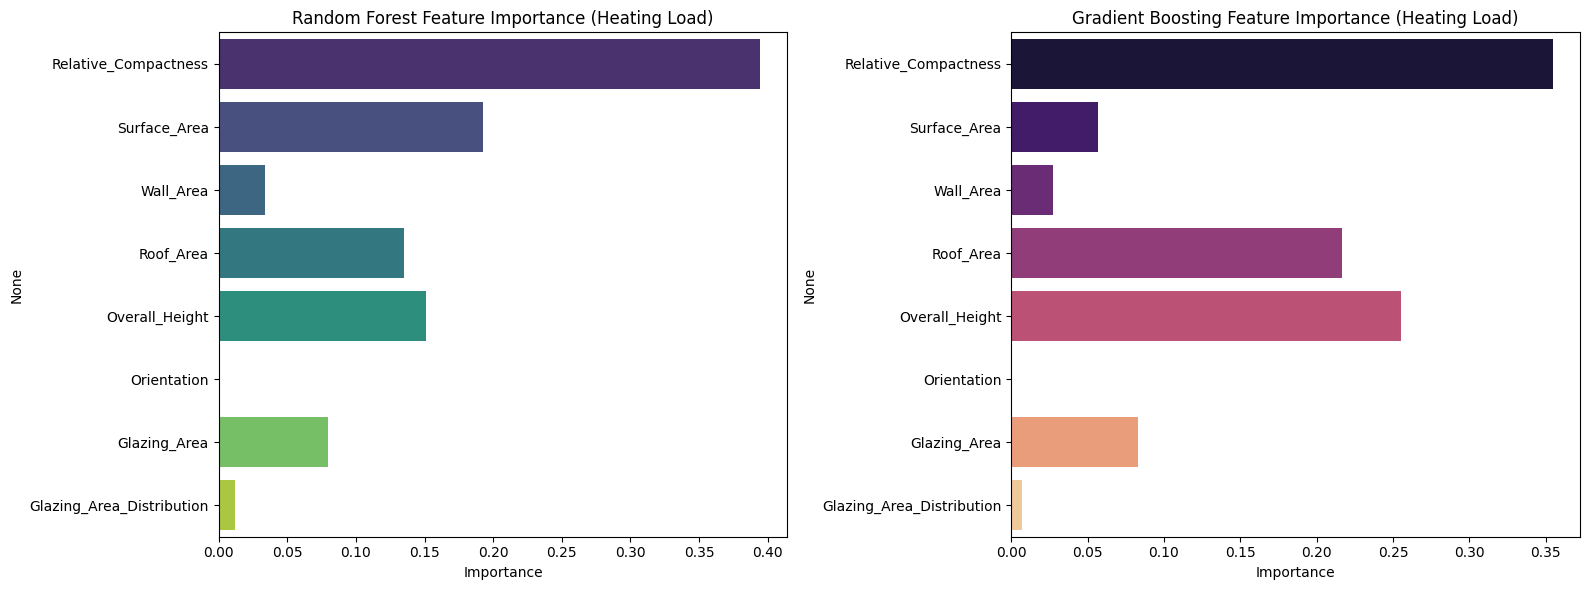

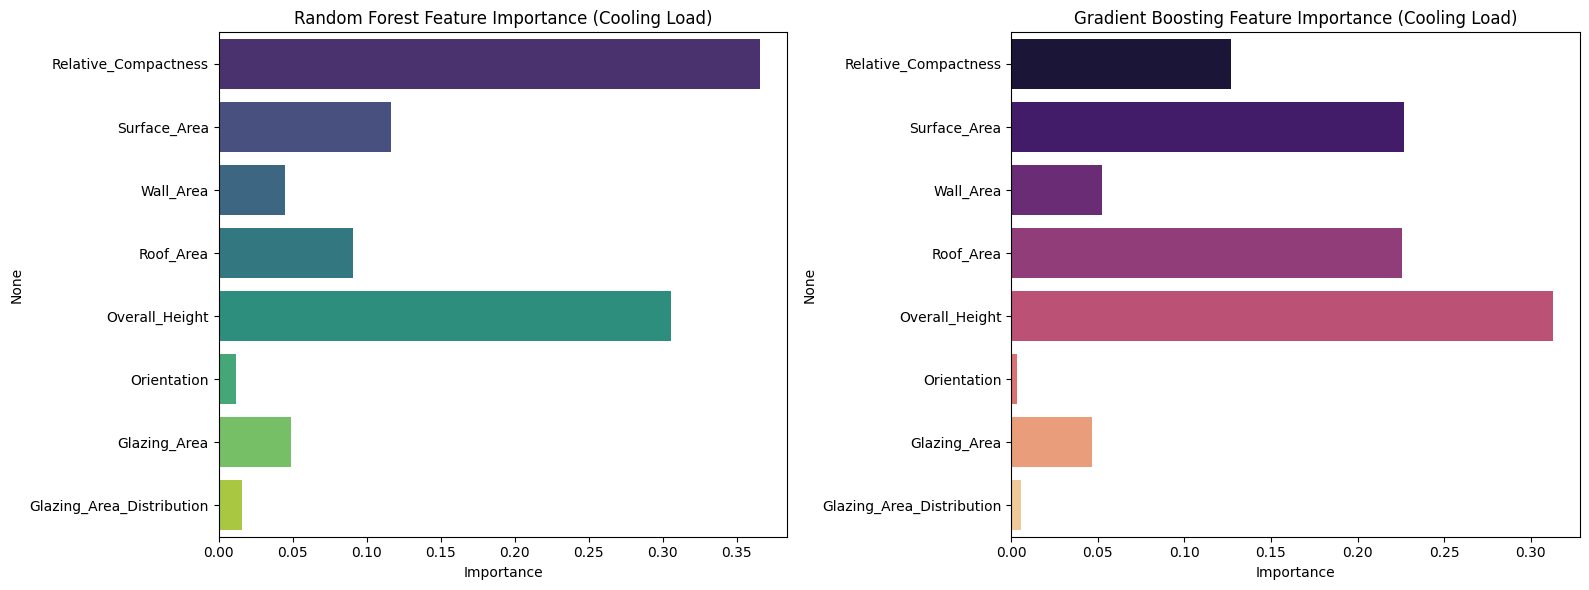

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('graphs', exist_ok=True)

feature_names = X.columns

# -------- Heating Load --------
rf_heat = results["Random Forest (Heating Load)"]["Model"]
gb_heat = results["Gradient Boosting (Heating Load)"]["Model"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=rf_heat.feature_importances_, y=feature_names, ax=axes[0], palette="viridis")
axes[0].set_title("Random Forest Feature Importance (Heating Load)")
axes[0].set_xlabel("Importance")

sns.barplot(x=gb_heat.feature_importances_, y=feature_names, ax=axes[1], palette="magma")
axes[1].set_title("Gradient Boosting Feature Importance (Heating Load)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig('graphs/feature_importance_heating.png')
plt.show()


# -------- Cooling Load --------
rf_cool = results["Random Forest (Cooling Load)"]["Model"]
gb_cool = results["Gradient Boosting (Cooling Load)"]["Model"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=rf_cool.feature_importances_, y=feature_names, ax=axes[0], palette="viridis")
axes[0].set_title("Random Forest Feature Importance (Cooling Load)")
axes[0].set_xlabel("Importance")

sns.barplot(x=gb_cool.feature_importances_, y=feature_names, ax=axes[1], palette="magma")
axes[1].set_title("Gradient Boosting Feature Importance (Cooling Load)")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig('graphs/feature_importance_cooling.png')
plt.show()

## E. Interpretability Analysis
We analyze interpretability using feature importance, sensitivity analysis, and partial dependence plots to understand how changes in input features affect predicted energy consumption.


Best model for Heating Load: Random Forest (Heating Load)

Sensitivity Test for Heating Load using Relative_Compactness


,Relative_Compactness,Predicted Heating Load
0,0.62,21.2572
1,0.71,20.6034
2,0.80,28.8065
3,0.89,25.8595
4,0.98,25.6611


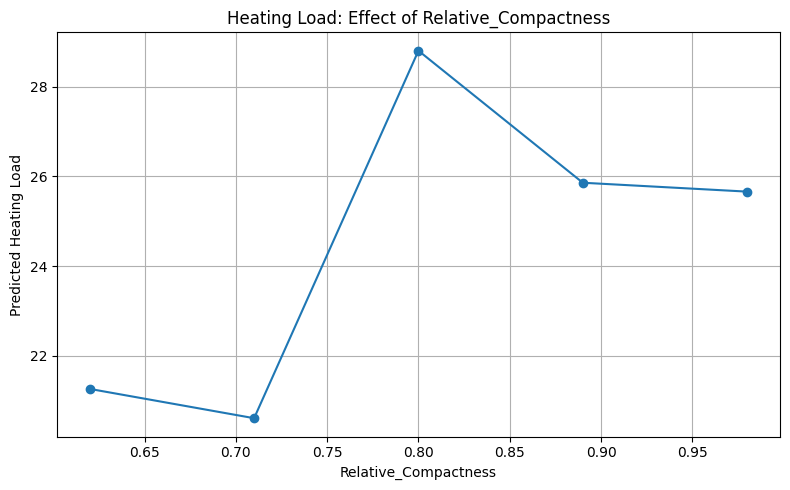

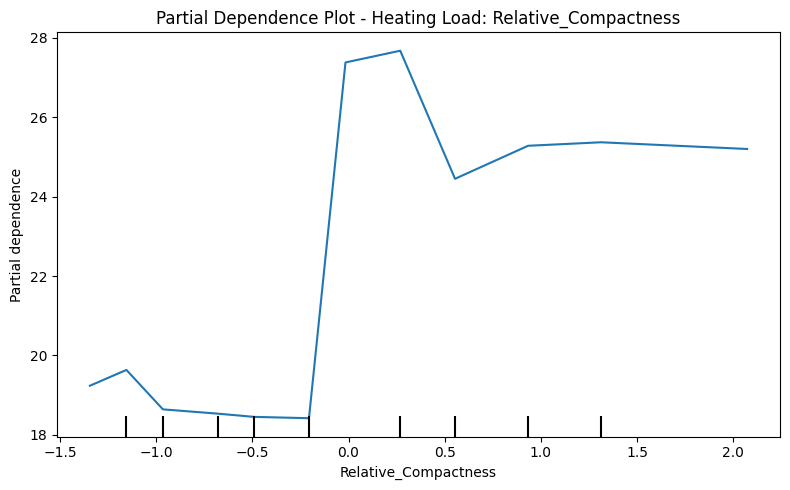


Sensitivity Test for Heating Load using Overall_Height


,Overall_Height,Predicted Heating Load
0,3.500,21.1403
1,4.375,21.1403
2,5.250,23.6075
3,6.125,23.6075
4,7.000,23.6075


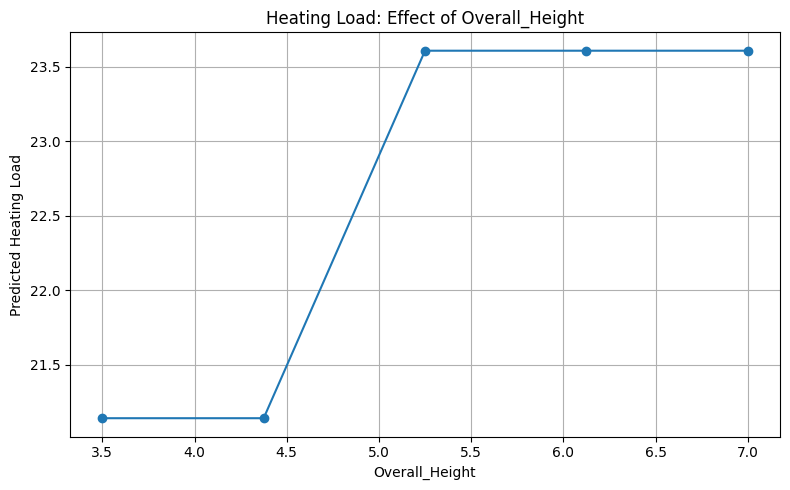

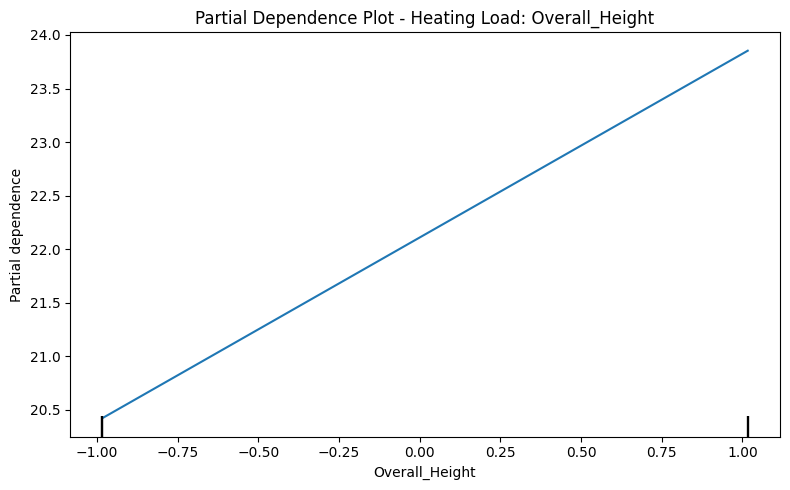


Sensitivity Test for Heating Load using Surface_Area


,Surface_Area,Predicted Heating Load
0,514.5,26.6060
1,588.0,26.6056
2,661.5,27.0373
3,735.0,23.8951
4,808.5,24.0139


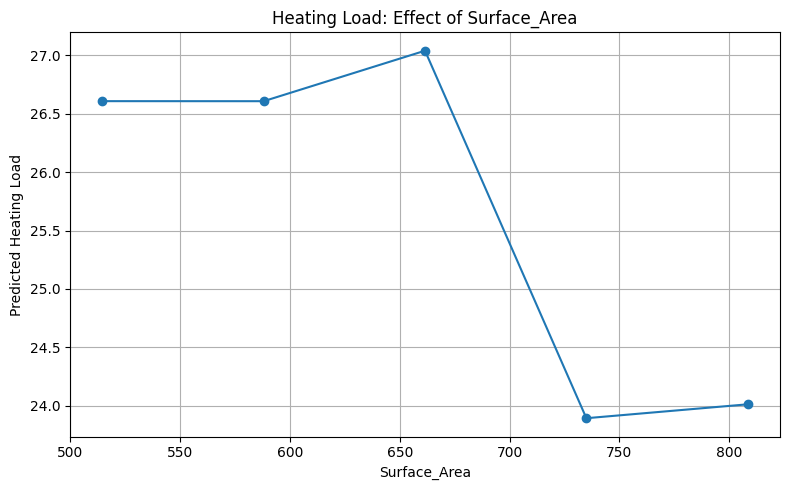

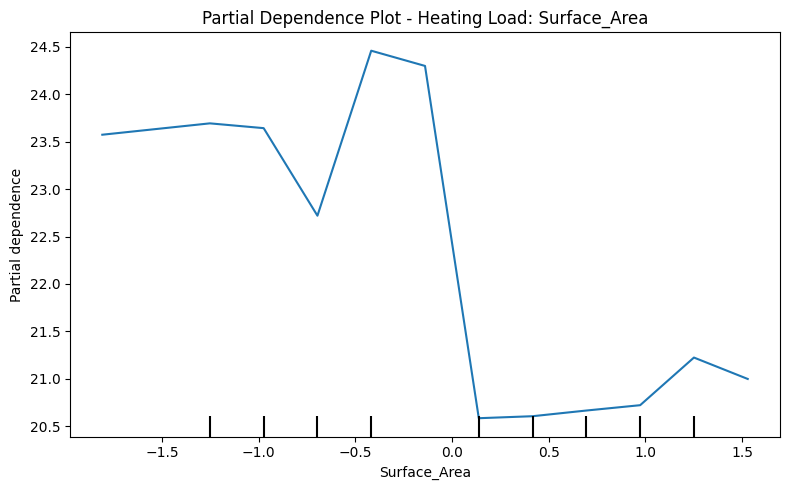


Sensitivity Test for Heating Load using Roof_Area


,Roof_Area,Predicted Heating Load
0,110.2500,23.6346
1,137.8125,23.6075
2,165.3750,23.6075
3,192.9375,21.3888
4,220.5000,21.3888


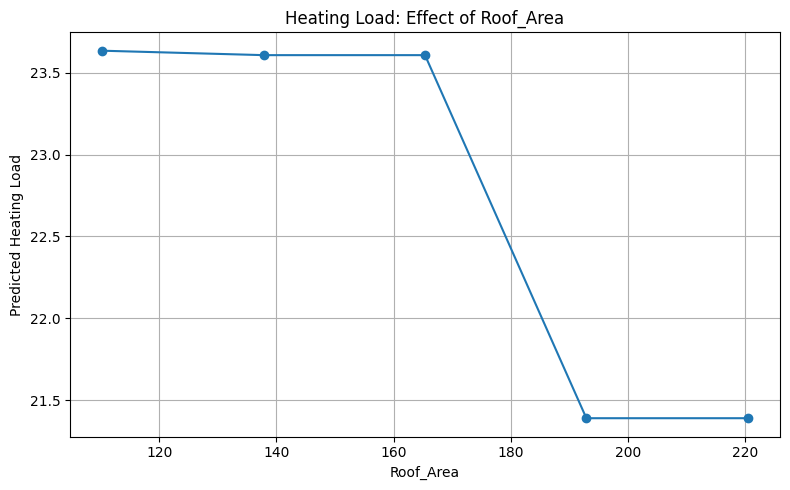

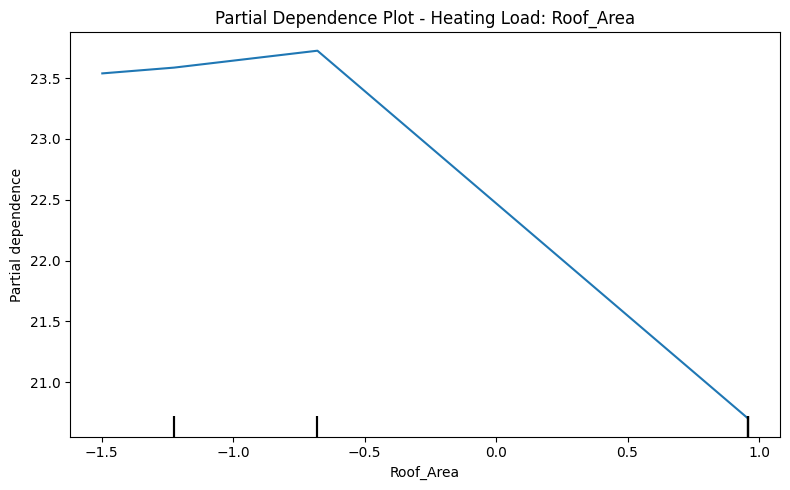


Best model for Cooling Load: MLP (Cooling Load)

Sensitivity Test for Cooling Load using Relative_Compactness


,Relative_Compactness,Predicted Cooling Load
0,0.62,27.124196
1,0.71,27.596034
2,0.80,28.281413
3,0.89,30.112581
4,0.98,31.722640


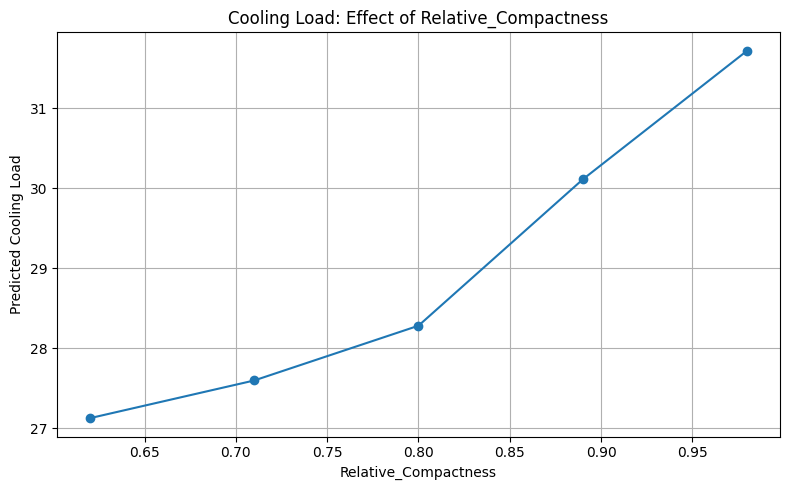

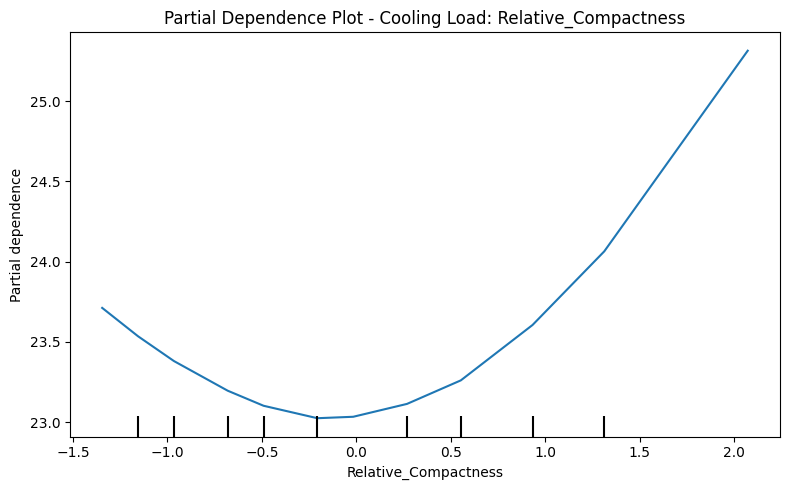


Sensitivity Test for Cooling Load using Overall_Height


,Overall_Height,Predicted Cooling Load
0,3.500,1.781033
1,4.375,6.291091
2,5.250,13.231497
3,6.125,20.846069
4,7.000,28.466381


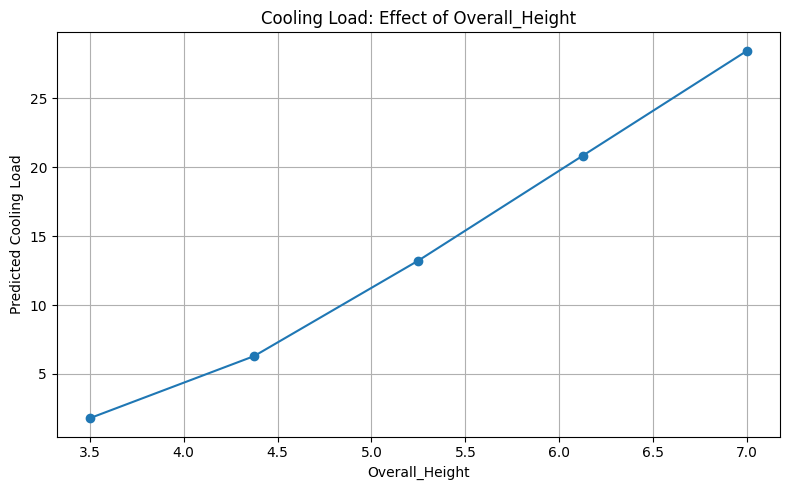

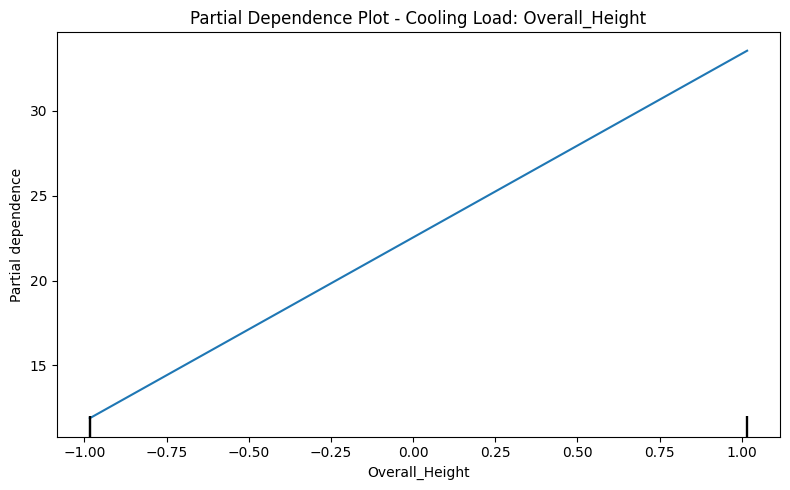


Sensitivity Test for Cooling Load using Surface_Area


,Surface_Area,Predicted Cooling Load
0,514.5,28.076211
1,588.0,28.189878
2,661.5,30.096165
3,735.0,32.840440
4,808.5,35.501798


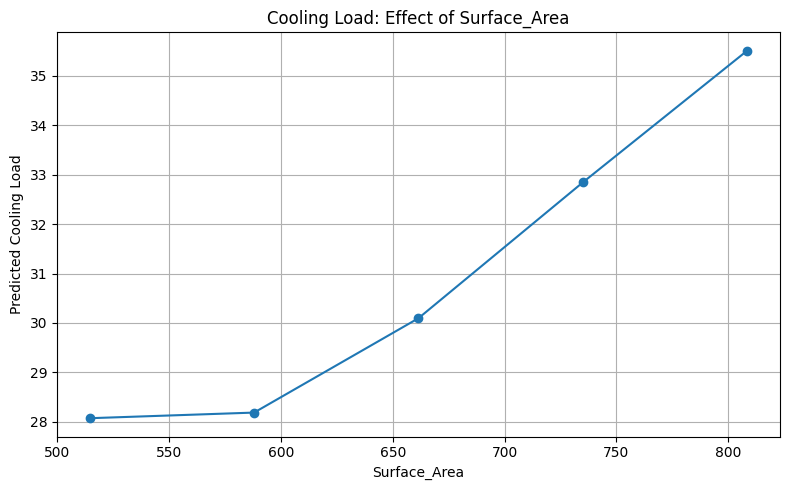

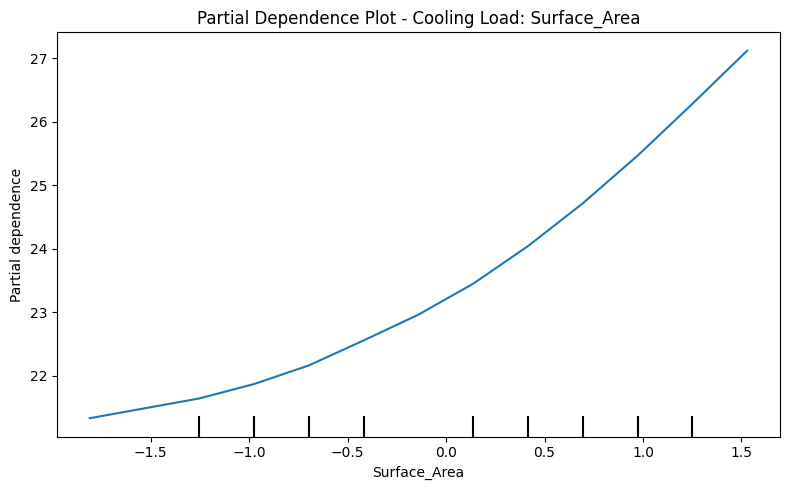


Sensitivity Test for Cooling Load using Roof_Area


,Roof_Area,Predicted Cooling Load
0,110.2500,32.828774
1,137.8125,29.504738
2,165.3750,30.536729
3,192.9375,32.933165
4,220.5000,32.450259


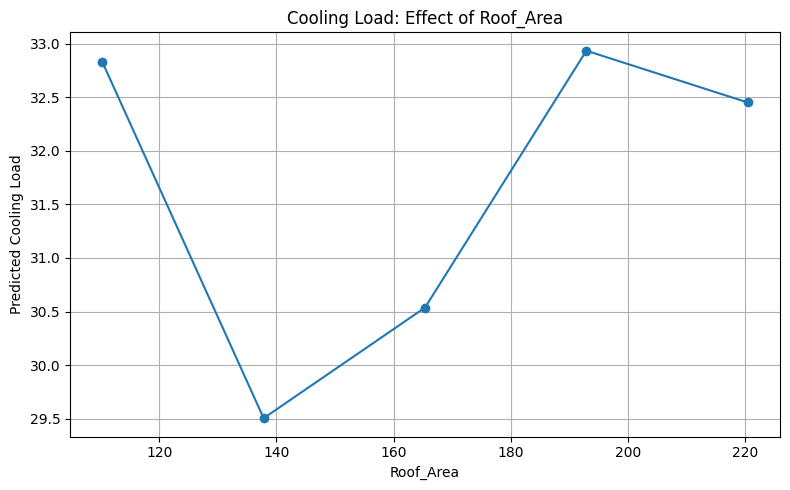

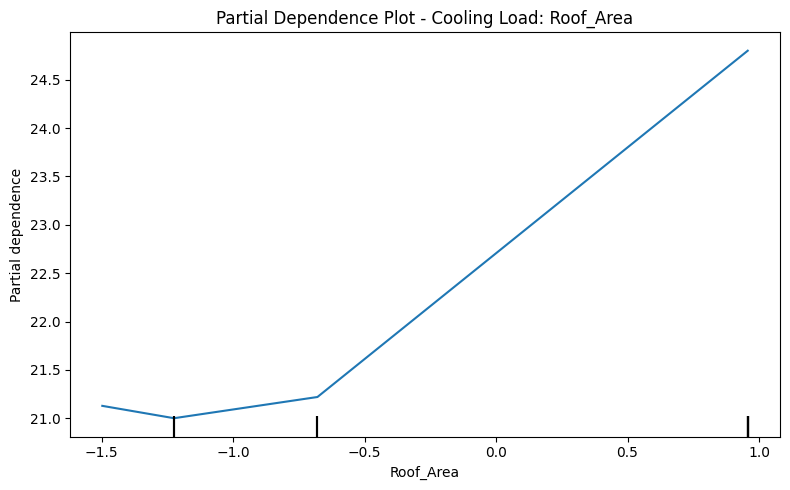

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay

scaler_heat = StandardScaler()
X_heat_train_scaled = scaler_heat.fit_transform(X_train)
X_heat_test_scaled = scaler_heat.transform(X_test)

scaler_cool = StandardScaler()
X_cool_train_scaled = scaler_cool.fit_transform(X_train)
X_cool_test_scaled = scaler_cool.transform(X_test)


def get_best_model(results_dict, target_keyword):
    filtered = {k: v for k, v in results_dict.items() if target_keyword in k}
    if not filtered:
        raise ValueError(f"No models found for target: {target_keyword}")
    best_name = min(filtered, key=lambda k: filtered[k]["MSE"])
    return best_name, filtered[best_name]["Model"]

def sensitivity_test(model, scaler, X_data, feature_name, values, target_name, base_index=0):
    base_row = X_data.iloc[base_index].copy()
    rows = []

    for val in values:
        temp_row = base_row.copy()
        temp_row[feature_name] = val

        temp_df = pd.DataFrame([temp_row], columns=X_data.columns)
        temp_scaled = scaler.transform(temp_df)
        pred = model.predict(temp_scaled)[0]

        rows.append({
            feature_name: val,
            f"Predicted {target_name}": pred
        })

    result_df = pd.DataFrame(rows)

    print(f"\nSensitivity Test for {target_name} using {feature_name}")
    try:
        display(result_df)
    except:
        print(result_df)

    plt.figure(figsize=(8, 5))
    plt.plot(result_df[feature_name], result_df[f"Predicted {target_name}"], marker='o')
    plt.xlabel(feature_name)
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"{target_name}: Effect of {feature_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return result_df

def plot_pdp(model, scaler, X_data, feature_name, target_name):
    X_scaled_df = pd.DataFrame(scaler.transform(X_data), columns=X_data.columns)

    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(
        model,
        X_scaled_df,
        features=[feature_name],
        ax=ax
    )
    plt.title(f"Partial Dependence Plot - {target_name}: {feature_name}")
    plt.tight_layout()
    plt.show()

features_to_test = [
    "Relative_Compactness",
    "Overall_Height",
    "Surface_Area",
    "Roof_Area"
]

targets = [
    {
        "name": "Heating Load",
        "X": X_train,
        "scaler": scaler_heat,
        "results": results
    },
    {
        "name": "Cooling Load",
        "X": X_train,
        "scaler": scaler_cool,
        "results": results
    }
]

base_index = 0

for target in targets:
    target_name = target["name"]
    X_data = target["X"]
    scaler = target["scaler"]
    results_dict = target["results"]

    best_model_name, best_model = get_best_model(results_dict, target_name)
    print(f"\nBest model for {target_name}: {best_model_name}")

    for feature_name in features_to_test:
        values = np.linspace(X_data[feature_name].min(), X_data[feature_name].max(), 5)

        sensitivity_test(
            model=best_model,
            scaler=scaler,
            X_data=X_data,
            feature_name=feature_name,
            values=values,
            target_name=target_name,
            base_index=base_index
        )

        plot_pdp(
            model=best_model,
            scaler=scaler,
            X_data=X_data,
            feature_name=feature_name,
            target_name=target_name
        )

## F. Visualization and Result Analysis
We compare performance using visualization charts and predicted VS actual energy consumption graphs.


### Final Model Performance Comparison

The tables below summarize the performance of all models for **Heating Load** and **Cooling Load** using five regression metrics:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination (R²)
- Mean Absolute Error (MAE)
- Mean Absolute Percentage Error (MAPE)

Models are ranked by **lowest MSE (best performance)**.

---

### Heating Load – Model Performance

| Model                              | MSE   | RMSE  | R²     | MAE   | MAPE (%) |
|-----------------------------------|-------|-------|--------|-------|----------|
| **Random Forest (Heating Load)**  | **0.247** | **0.497** | **0.998** | **0.358** | **1.49** |
| Gradient Boosting (Heating Load)  | 0.265 | 0.515 | 0.997 | 0.386 | 1.75 |
| MLP (Heating Load)                | 1.114 | 1.055 | 0.989 | 0.764 | 3.32 |
| Linear Regression (Heating Load)  | 9.153 | 3.025 | 0.912 | 2.182 | 10.26 |

---

### Cooling Load – Model Performance

| Model                              | MSE   | RMSE  | R²     | MAE   | MAPE (%) |
|-----------------------------------|-------|-------|--------|-------|----------|
| **MLP (Cooling Load)**            | **2.181** | **1.477** | **0.976** | 1.076 | 4.19 |
| Gradient Boosting (Cooling Load)  | 2.293 | 1.514 | 0.975 | 1.057 | 3.78 |
| Random Forest (Cooling Load)      | 2.978 | 1.726 | 0.968 | 1.073 | 3.55 |
| Linear Regression (Cooling Load)  | 9.893 | 3.145 | 0.893 | 2.195 | 8.48 |

---

### Combined Comparison (Heating vs Cooling)

| Model | Heating MSE | Cooling MSE | Heating R² | Cooling R² |
|------|------------|------------|-----------|-----------|
| Random Forest | **0.247** | 2.978 | **0.998** | 0.968 |
| Gradient Boosting | 0.265 | 2.293 | 0.997 | 0.975 |
| MLP | 1.114 | **2.181** | 0.989 | **0.976** |
| Linear Regression | 9.153 | 9.893 | 0.912 | 0.893 |

---

### Key Insights

- **Random Forest** performs best for **Heating Load**, achieving the lowest error and highest R².
- **MLP (Neural Network)** performs best for **Cooling Load**, slightly outperforming tree-based models.
- **Gradient Boosting** consistently performs well across both targets.
- **Linear Regression** performs significantly worse, indicating that the problem is **non-linear**.

---

### Note

Tree-based ensemble models generally perform strongly on structured tabular data.  
However, results show that **no single model dominates across both targets**, highlighting the importance of evaluating models separately for different prediction tasks.

Heating Load - Models Ranked by Performance (Lowest MSE is Best):


,MSE,RMSE,R2,MAE,MAPE
Random Forest (Heating Load),0.247323,0.497316,0.997627,0.358242,1.493768
Gradient Boosting (Heating Load),0.265311,0.515083,0.997455,0.386133,1.746873
MLP (Heating Load),1.113913,1.055421,0.989313,0.763955,3.319130
Linear Regression (Heating Load),9.153208,3.025427,0.912185,2.182073,10.258890



Cooling Load - Models Ranked by Performance (Lowest MSE is Best):


,MSE,RMSE,R2,MAE,MAPE
MLP (Cooling Load),2.180651,1.476703,0.976465,1.076094,4.187925
Gradient Boosting (Cooling Load),2.293485,1.514426,0.975248,1.057285,3.782890
Random Forest (Cooling Load),2.977797,1.725629,0.967862,1.072605,3.546231
Linear Regression (Cooling Load),9.893428,3.145382,0.893226,2.195295,8.478724


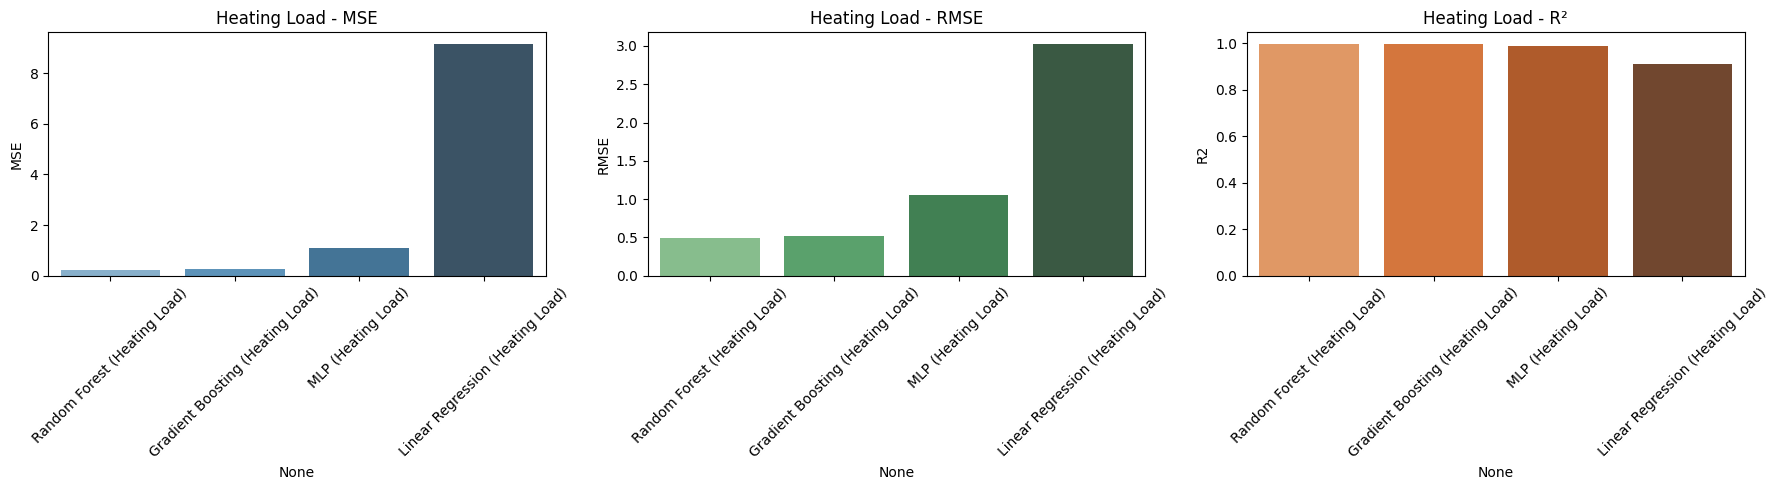

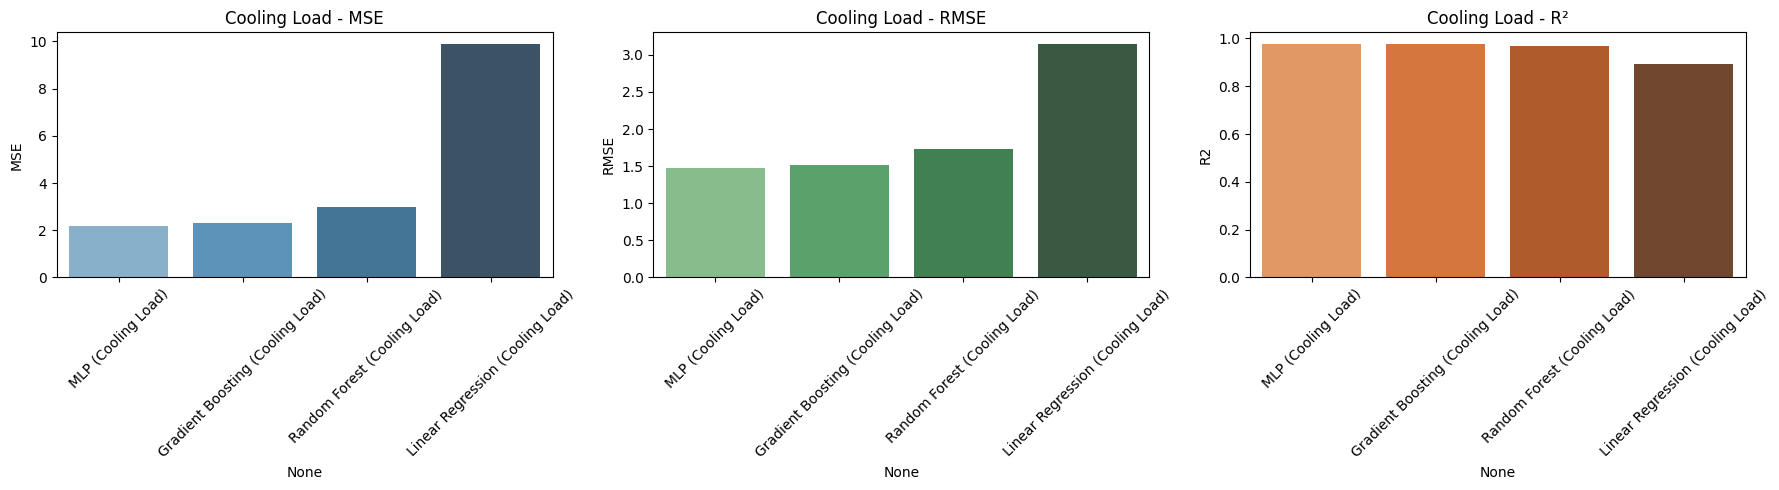

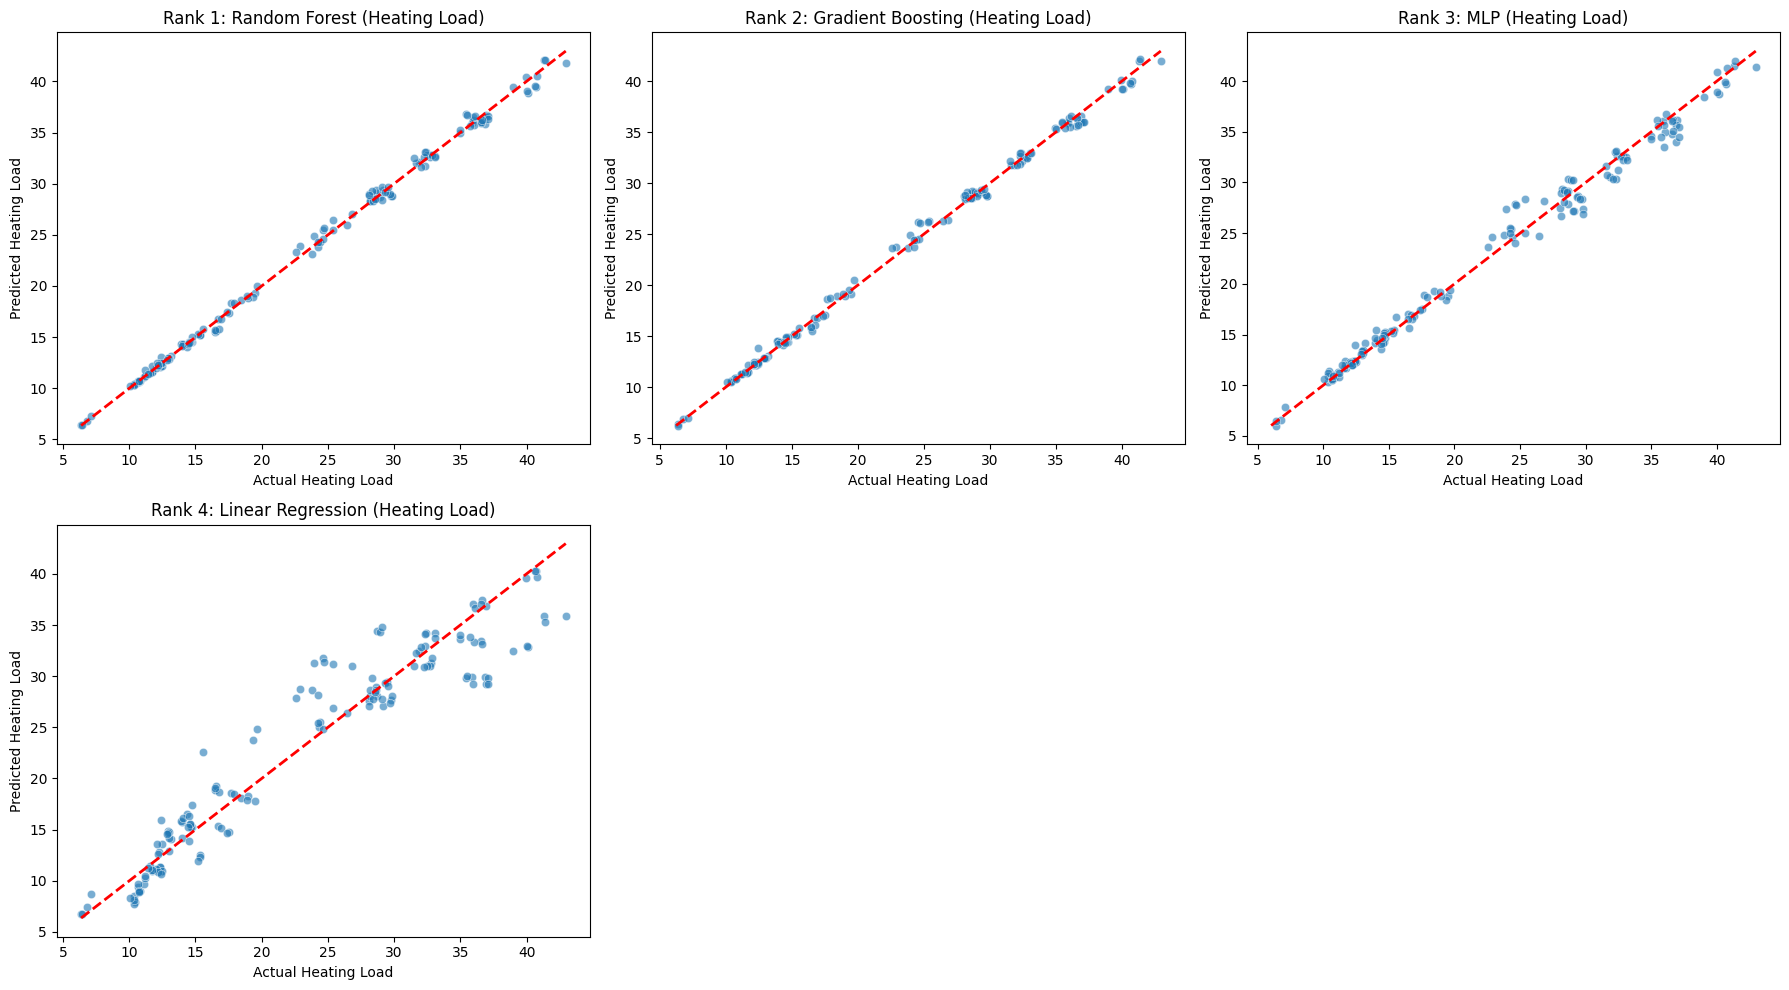

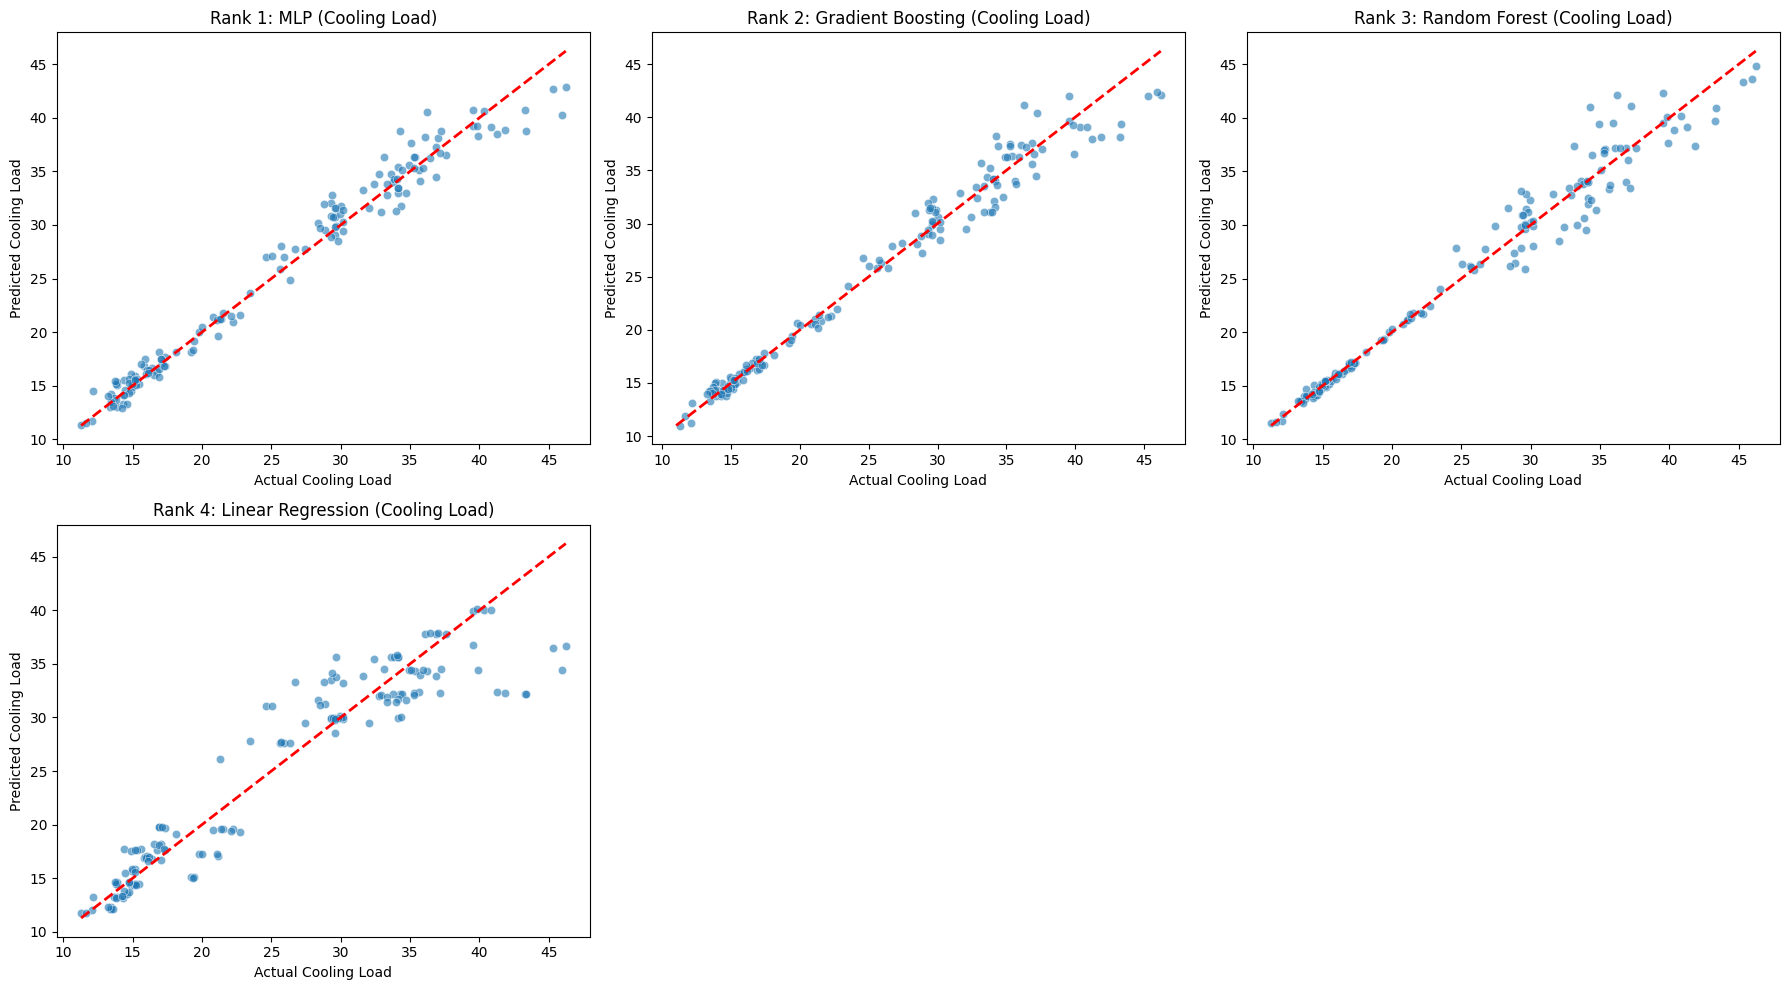

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('graphs', exist_ok=True)

results_heat = {
    model: metrics for model, metrics in results.items()
    if "Heating Load" in model
}

results_cool = {
    model: metrics for model, metrics in results.items()
    if "Cooling Load" in model
}

def build_metrics_df(results_dict):
    metrics_df = pd.DataFrame({
        model: [metrics["MSE"], metrics["RMSE"], metrics["R2"], metrics["MAE"], metrics["MAPE"]]
        for model, metrics in results_dict.items()
    }, index=["MSE", "RMSE", "R2", "MAE", "MAPE"]).T

    metrics_df = metrics_df.sort_values(by="MSE", ascending=True)
    return metrics_df

metrics_df_heat = build_metrics_df(results_heat)
metrics_df_cool = build_metrics_df(results_cool)

print("Heating Load - Models Ranked by Performance (Lowest MSE is Best):")
try:
    display(metrics_df_heat)
except:
    print(metrics_df_heat)

print("\nCooling Load - Models Ranked by Performance (Lowest MSE is Best):")
try:
    display(metrics_df_cool)
except:
    print(metrics_df_cool)

def plot_metrics(metrics_df, title_suffix, save_name):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.barplot(x=metrics_df.index, y=metrics_df["MSE"], ax=axes[0], palette="Blues_d")
    axes[0].set_title(f"{title_suffix} - MSE")
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(x=metrics_df.index, y=metrics_df["RMSE"], ax=axes[1], palette="Greens_d")
    axes[1].set_title(f"{title_suffix} - RMSE")
    axes[1].tick_params(axis='x', rotation=45)

    sns.barplot(x=metrics_df.index, y=metrics_df["R2"], ax=axes[2], palette="Oranges_d")
    axes[2].set_title(f"{title_suffix} - R²")
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f'graphs/{save_name}')
    plt.show()

plot_metrics(metrics_df_heat, "Heating Load", "performance_comparison_heating.png")
plot_metrics(metrics_df_cool, "Cooling Load", "performance_comparison_cooling.png")


def plot_predicted_vs_actual(results_dict, y_test, metrics_df, title_suffix, save_name):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    ranked_models = metrics_df.index.tolist()

    for i, model_name in enumerate(ranked_models):
        if i >= len(axes):
            break

        preds = results_dict[model_name]["Predictions"]
        sns.scatterplot(x=y_test, y=preds, ax=axes[i], alpha=0.6)

        min_val = min(y_test.min(), preds.min())
        max_val = max(y_test.max(), preds.max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

        axes[i].set_title(f"Rank {i+1}: {model_name}")
        axes[i].set_xlabel(f"Actual {title_suffix}")
        axes[i].set_ylabel(f"Predicted {title_suffix}")

    for j in range(len(ranked_models), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(f'graphs/{save_name}')
    plt.show()

plot_predicted_vs_actual(
    results_heat,
    y_heat_test,
    metrics_df_heat,
    "Heating Load",
    "predicted_vs_actual_heating.png"
)

plot_predicted_vs_actual(
    results_cool,
    y_cool_test,
    metrics_df_cool,
    "Cooling Load",
    "predicted_vs_actual_cooling.png"
)